# `characterization.ipynb`


**Performs an Exploratory Data Analysis (EDA).**

  - This notebook was initially developed by a student from Piauí. I quickly reviewed the figure generation, but I suspect errors in data filtering for figure generation. It would be beneficial to debug the entire process to ensure data accuracy before proceeding with further analyses.  
  - From the `video_id` field in the comments file, channel and video information should be extracted from the respective files in the `raw_data` folder. Note that the information considered about videos and channels should initially focus only on IDs present in the filtered comments file located at `cleaned_data/final_comments_depre_match.csv`.  
  - Our goal here is to perform an Exploratory Data Analysis (EDA), testing hypotheses related to user behavior at different times, such as late night, midnight, etc.  
  - Only after a complete characterization, we will move on to model creation. Take a look at this study here, but we will aim for a more refined approach:  
    https://www.researchgate.net/profile/Carlos-G-Ferreira/publication/383662803_Analise_da_Percepcao_do_Uso_de_Cigarros_Eletronicos_no_Brasil_por_meio_de_Comentarios_no_YouTube/links/66d5ecc0f84dd1716c7904e1/Analise-da-Percepcao-do-Uso-de-Cigarros-Eletronicos-no-Brasil-por-meio-de-Comentarios-no-YouTube.pdf
  

**After completing this analysis, we will go to the meeting with the medical staff and define the creation of the model.**  

 
 ### Enhancements:

`@Guilherme O. S.`: 

- Cleaned the code

---


## Imports and Definitions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")
plt.style.use('seaborn-v0_8')

df = pd.read_csv("cleaned_data/comments_info_language_roBERTa_substring.csv", 
                on_bad_lines='skip', 
                encoding='utf-8',
                sep=',',
                lineterminator='\n')
# df.head(1)

df.columns

Index(['video_id', 'comment_id', 'author', 'author_profile_image_url',
       'author_channel_url', 'author_channel_id', 'comment', 'published_at',
       'updated_at', 'like_count', 'viewer_rating', 'can_rate', 'is_reply',
       'parent_id', 'channel_id', 'language'],
      dtype='object')


Videos per month:
month_year  count
   2019-04      3
   2019-05      1
   2019-06     11
   2019-09    413
   2019-10  16214
   2019-11  20312
   2019-12  12616
   2020-01  23253
   2020-02  24906
   2020-03  41691
   2020-04  44138
   2020-05  34124
   2020-06  19332
   2020-07  25016
   2020-08  19642
   2020-09  30782
   2020-10  37391
   2020-11  36188
   2020-12  17591
   2021-01  37296
   2021-02  20589
   2021-03  20649
   2021-04  20968
   2021-05  46815
   2021-06  30199
   2021-07  33857
   2021-08  43936
   2021-09  29884
   2021-10  28493
   2021-11  31222
   2021-12  21108
   2022-01  43280
   2022-02  18313
   2022-03  19463
   2022-04  24886
   2022-05  24889
   2022-06  27419
   2022-07  34081
   2022-08  29393
   2022-09  28844
   2022-10  32815
   2022-11  25333
   2022-12  26786
   2023-01  33491
   2023-02  31379
   2023-03  28426
   2023-04  28225
   2023-05  41189
   2023-06  28186
   2023-07  36888
   2023-08  36175
   2023-09  29321
   2023-10  51540
   2023-1

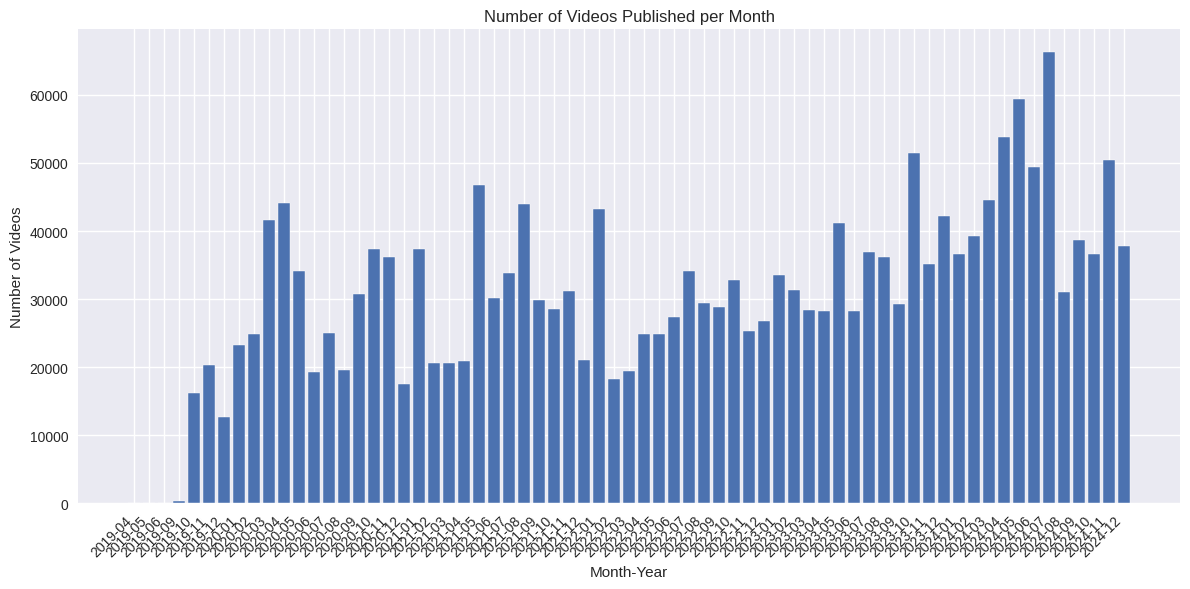

In [2]:
# Convert published_at to datetime and extract month-year
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.strftime('%Y-%m')

# Group by month and count videos
monthly_counts = df.groupby('month_year').size().reset_index(name='count')
monthly_counts = monthly_counts.sort_values('month_year')

# Display counts
print("\nVideos per month:")
print(monthly_counts.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.bar(monthly_counts['month_year'], monthly_counts['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Number of Videos Published per Month')
plt.xlabel('Month-Year')
plt.ylabel('Number of Videos')
plt.tight_layout()
plt.show()

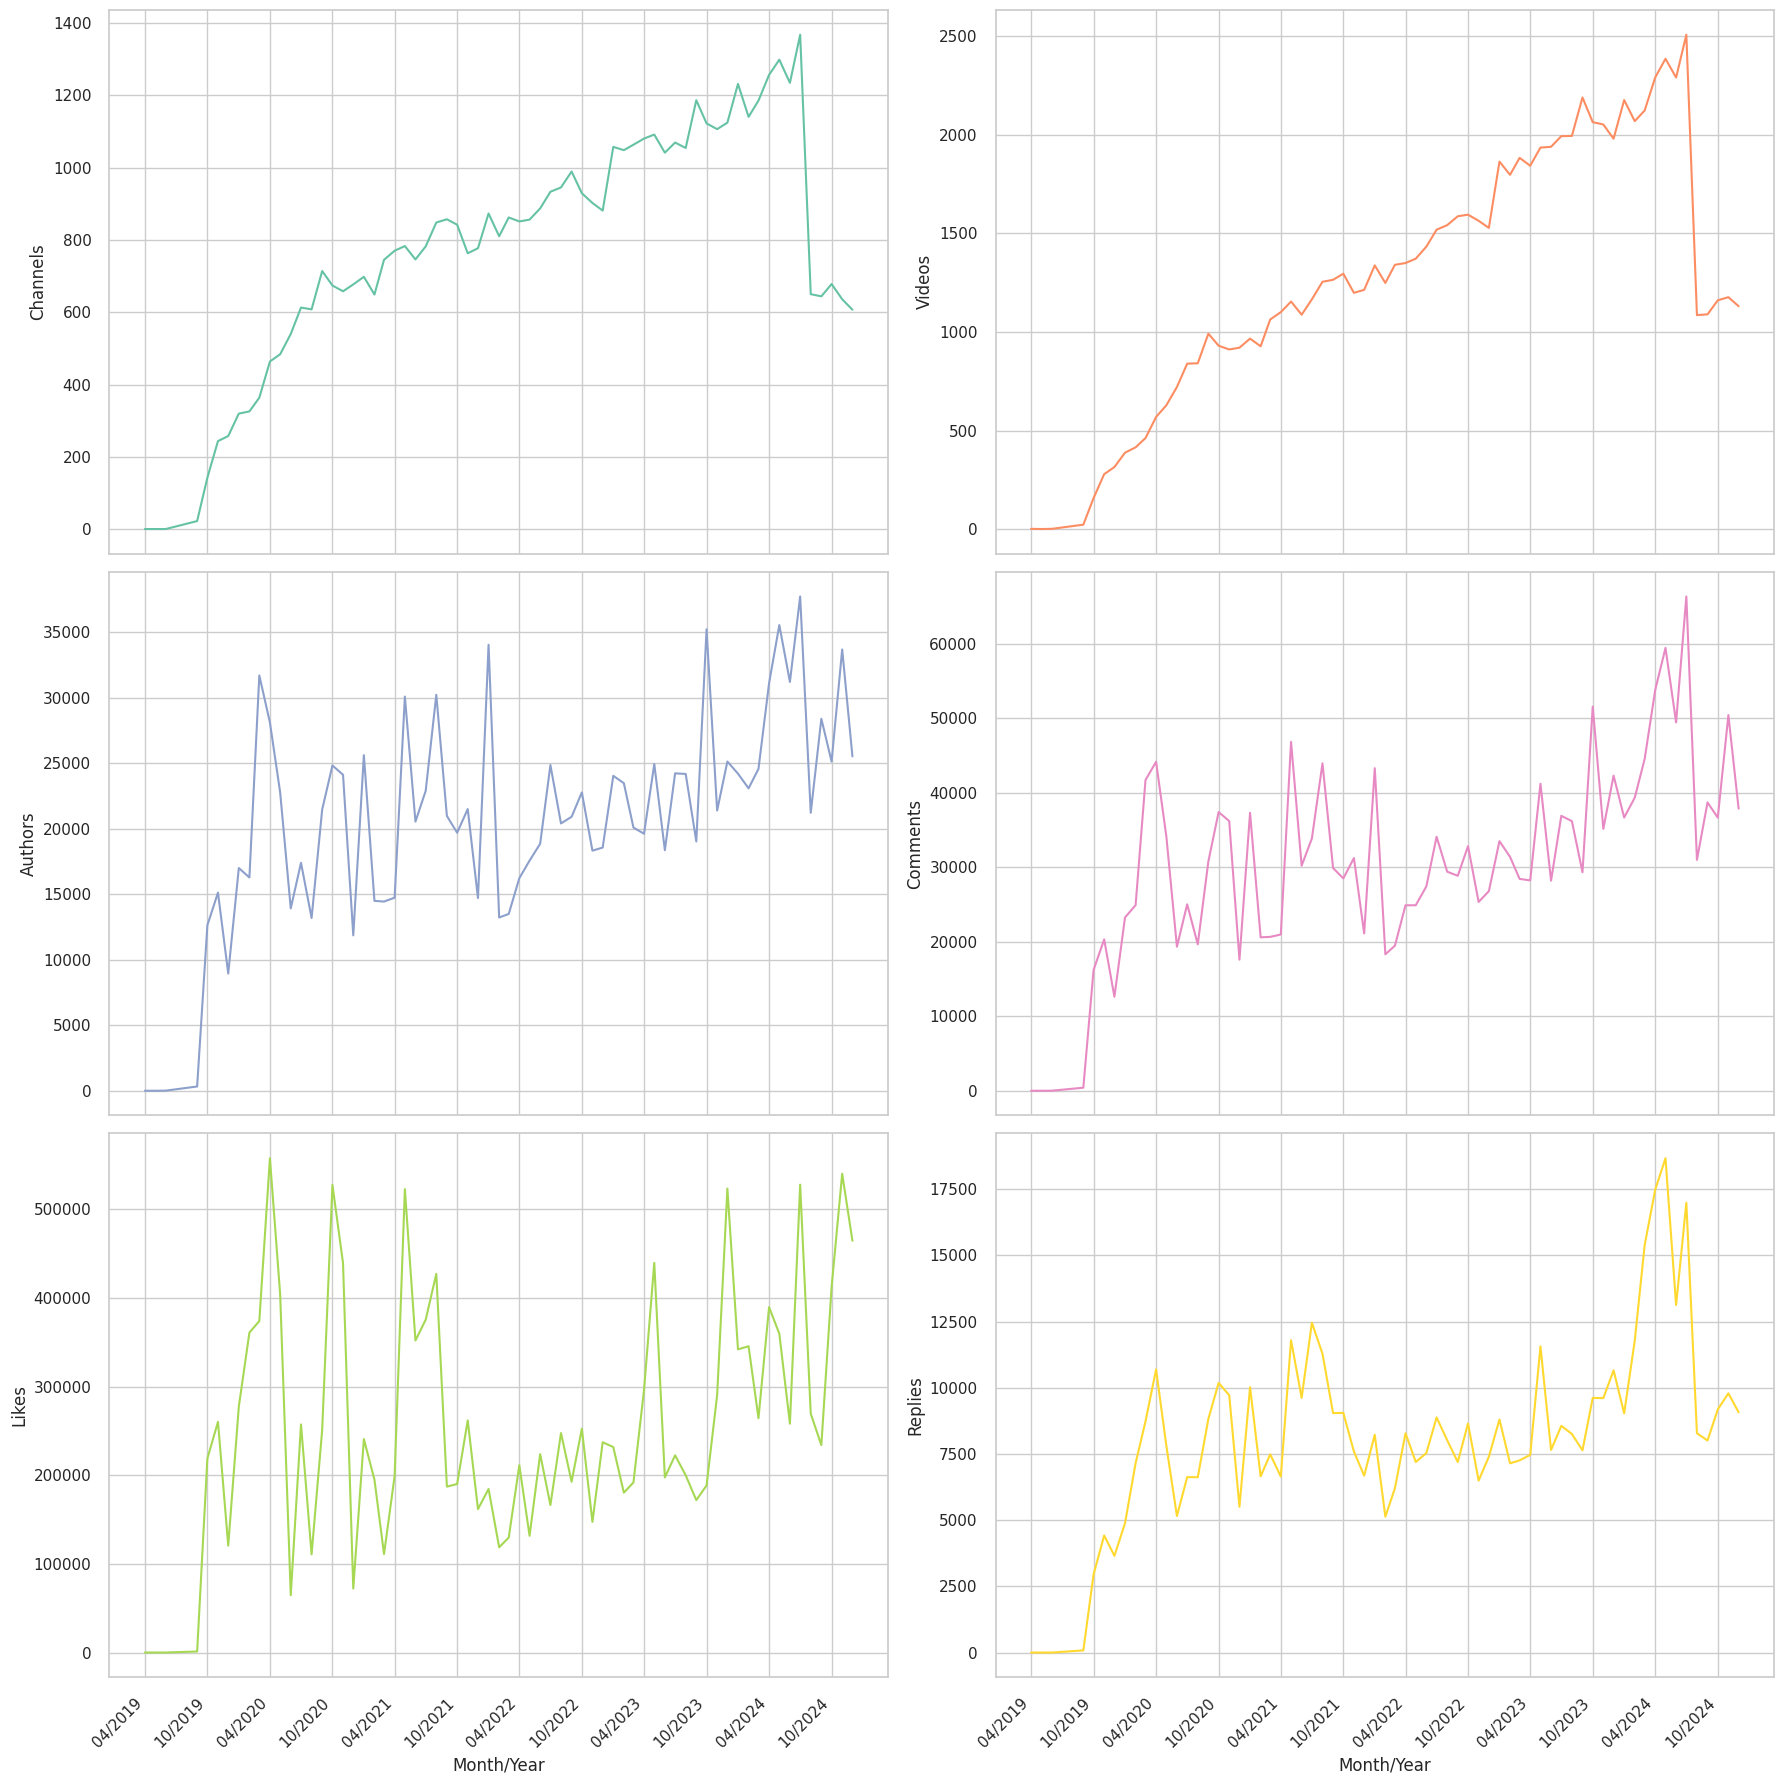

In [3]:
def adjust_ticks(ax, monthly_data):
    # Generate tick positions for every 6 months, up to max date of Dec 31, 2024
    tick_positions = pd.date_range(
        start=monthly_data['month_year'].min(),
        end='2024-12-31',
        freq='6MS'
    )
    tick_labels = [pos.strftime('%m/%Y') for pos in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')

# Convert published_at to datetime
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.strftime('%m/%Y')

# Aggregate data monthly
monthly_data = df.groupby('month_year').agg(
    unique_channels=('channel_id', 'nunique'), 
    videos=('video_id', 'nunique'),
    comments=('comment_id', 'size'),
    likes=('like_count', 'sum'),
    replies=('is_reply', 'sum'),
    unique_users=('author', 'nunique'),

).reset_index()

# Sort data by month_year
monthly_data['month_year'] = pd.to_datetime(monthly_data['month_year'], format='%m/%Y')
monthly_data.sort_values('month_year', inplace=True)

# List of metrics and their corresponding labels
metrics = ['unique_channels', 'videos',  'unique_users', 'comments', 'likes', 'replies']
labels = [ 'Channels', 'Videos', 'Authors', 'Comments', 'Likes', 'Replies']

sns.set_theme(style="whitegrid")
colors = sns.color_palette("Set2", len(metrics))

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18,18), sharex=True)

for ax, metric, label, c in zip(axs.flatten()[:6], metrics, labels, colors):
    sns.lineplot(data=monthly_data, x='month_year', y=metric, ax=ax, color=c)
    ax.set_ylabel(label)
    ax.set_xlabel("Month/Year")
    ax.tick_params(axis='x', rotation=45)
    adjust_ticks(ax, monthly_data)

if len(axs.flatten()) > len(metrics):
    for unused_ax in axs.flatten()[len(metrics):]:
        unused_ax.set_visible(False)

plt.tight_layout()
plt.show()


# EDA

### Cumulative distribution function

shows the cumulative probability of a random variable $X$ being less than or equal to a specific value $X$.

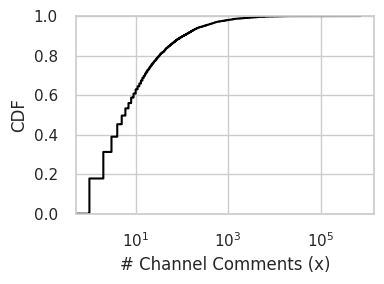

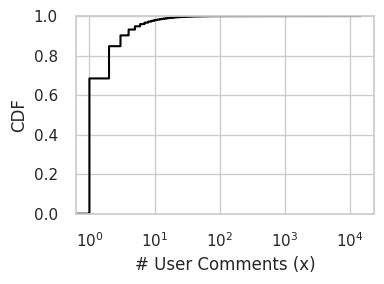

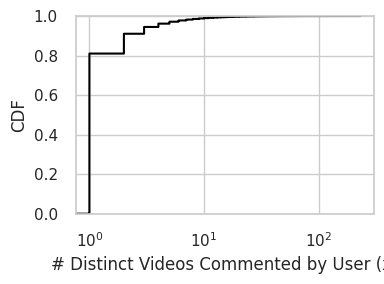

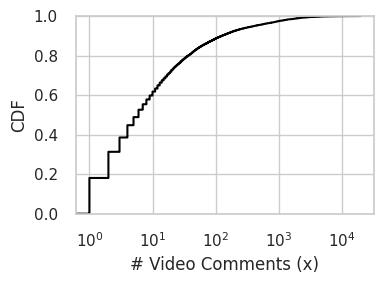

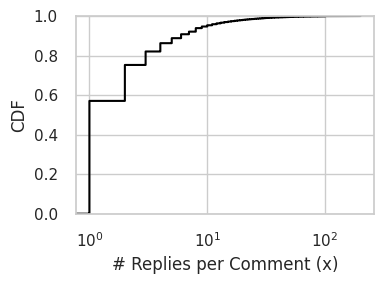

In [4]:
def plot_cdf(data, x_column, xlabel, figsize=(4, 3)):
    plt.figure(figsize=figsize)
    sns.ecdfplot(data=data, x=x_column, color='black')
    plt.xlabel(xlabel)
    plt.ylabel('CDF')
    plt.xscale('log')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

metrics = {
    'channel_comments': df.groupby('channel_id').size(),
    'user_comments': df.groupby('author').size(),
    'user_videos': df.groupby('author')['video_id'].nunique(),
    'video_comments': df.groupby('video_id').size(),
    'replies_per_comment': df[df['is_reply'] == True].groupby('parent_id').size()
}

plot_data = {
    name: data.reset_index(name='count') 
    for name, data in metrics.items()
}

plots = [
    ('channel_comments', 'count', '# Channel Comments (x)'),
    ('user_comments', 'count', '# User Comments (x)'),
    ('user_videos', 'count', '# Distinct Videos Commented by User (x)'),
    ('video_comments', 'count', '# Video Comments (x)'),
    ('replies_per_comment', 'count', '# Replies per Comment (x)')
]
for data_key, x_col, xlabel in plots:
    plot_cdf(plot_data[data_key], x_col, xlabel)

### Per Group and time

# Brief Textual Analysis (Exploratory)

## Identificando sentimento para todas as linhas

**Nuvem de palavras**

**TF-IDF dos comentários mais discriminativos**

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smartdata_ig/c.ferreira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


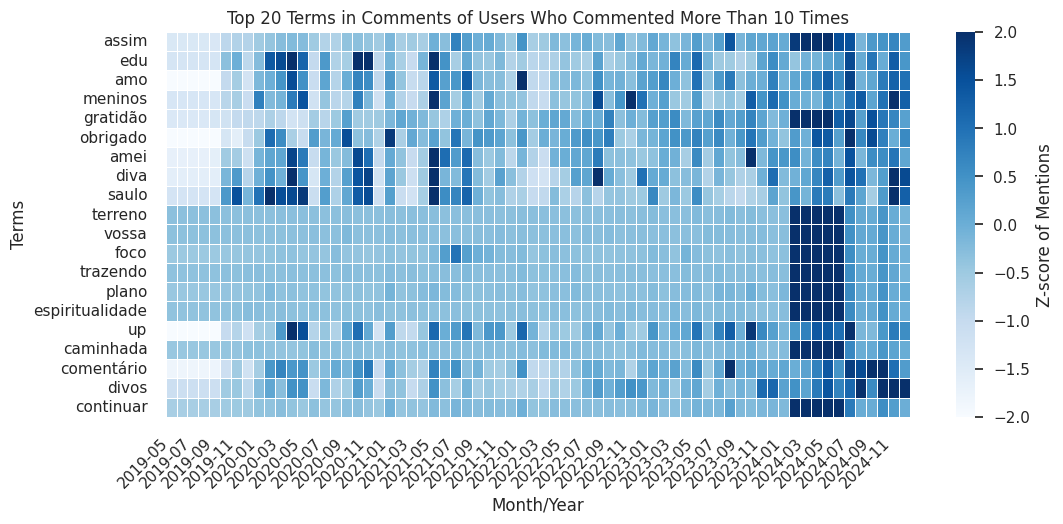

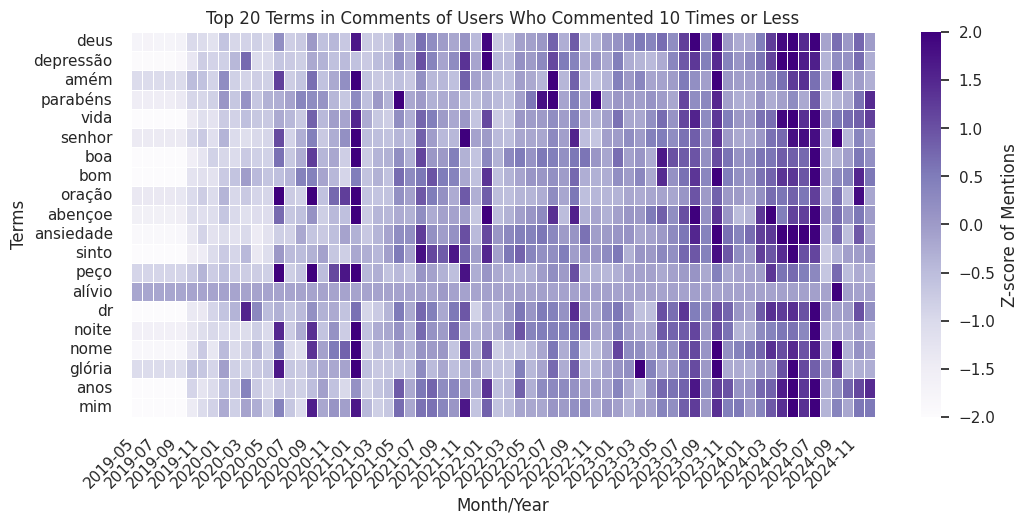

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import zscore
from nltk.corpus import stopwords
import nltk

# Certifique-se de baixar as stopwords do NLTK se ainda não tiver feito isso
nltk.download('stopwords')

# Obter stopwords em português
stop_words = set(stopwords.words('portuguese'))

# Adicionar stopwords personalizadas
custom_stopwords = set([
    'vai', 'ser', 'tá', 'tão', 'pra', 'né', 'vc', 'pq', 'isso', 'coisa', "vídeo", "video",
    'gente', 'aí', 'http', 'www', 'com', 'br', 'onde', 'tipo',"oi", "tô", "to", 
    "mano", "https", "sim", "não", "todos", "foda", "cara", "olá", "então", "faz", "vcs", "tá", 
    "ta", "kkk","kkkk","kkkkk","kkkkkk","kkkkkkk","kkkkkkkk", "fih"
])

# Atualizar as stopwords com as palavras personalizadas
stop_words.update(custom_stopwords)
stop_words = list(stop_words)  # Converter o conjunto atualizado para uma lista

# Convert 'published_at' to datetime if it's not already in datetime format
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.strftime('%Y-%m')

# Criar a classe de usuário com base na atividade
df['user_activity'] = df.groupby('author')['author'].transform('count')
df['user_class'] = df['user_activity'].apply(lambda x: 'High Activity' if x > 10 else 'Low Activity')

# Separar os comentários pelos dois grupos de usuários
high_activity_comments = df[df['user_class'] == 'High Activity']['comment']
low_activity_comments = df[df['user_class'] == 'Low Activity']['comment']

# Combinar os comentários em um DataFrame com a classe de usuário como rótulo
all_comments = pd.concat([high_activity_comments, low_activity_comments])
all_comments = all_comments.apply(str)
labels = ['High Activity'] * len(high_activity_comments) + ['Low Activity'] * len(low_activity_comments)

# Criar o TF-IDF vetor considerando ambos os grupos juntos
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words=stop_words)
tfidf_matrix = tfidf_vectorizer.fit_transform(all_comments)

# Obter os termos e seus scores TF-IDF
terms = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()

# Calcular a média dos scores TF-IDF para cada grupo de usuários
high_activity_scores = tfidf_scores[:len(high_activity_comments)].mean(axis=0)
low_activity_scores = tfidf_scores[len(high_activity_comments):].mean(axis=0)

# Calcular a diferença entre os grupos para encontrar os termos mais discriminativos
score_diff = high_activity_scores - low_activity_scores

# Obter os termos mais representativos para cada grupo
top_high_activity_terms = [terms[i] for i in score_diff.argsort()[-20:][::-1]]
top_low_activity_terms = [terms[i] for i in score_diff.argsort()[:20]]

# Função para criar heatmaps
def plot_heatmap(term_list, color_map, title):
    # Inicializar um DataFrame para armazenar as contagens
    term_counts = pd.DataFrame(0, index=date_range.strftime('%Y-%m'), columns=term_list)

    # Contar a ocorrência de cada termo por mês
    for term in term_list:
        term_df = df[df['comment'].str.contains(term, case=False, na=False)]
        monthly_counts = term_df.groupby('month_year').size()
        term_counts[term].update(monthly_counts)

    # Remover colunas que são totalmente nulas
    term_counts = term_counts.loc[:, (term_counts != 0).any(axis=0)]

    # Normalizar o DataFrame pelo Z-score por coluna
    term_counts_zscore = term_counts.apply(zscore)

    # Plotar o heatmap
    plt.figure(figsize=(12, 5))
    sns.heatmap(term_counts_zscore.T, cmap=color_map, cbar_kws={'label': 'Z-score of Mentions'}, linewidths=.5, vmin=-2, vmax=2)
    plt.title(title)
    plt.xlabel('Month/Year')
    plt.ylabel('Terms')

    # Personalizar os ticks do eixo X
    plt.xticks(rotation=45, ha='right')

    # Mostrar o gráfico
    plt.show()
    plt.close()

# Criar um range de datas para o DataFrame
date_range = pd.date_range(start=df['published_at'].min(), end=df['published_at'].max(), freq='MS')

# Plotar heatmap para os termos dos usuários de alta atividade
plot_heatmap(top_high_activity_terms, 'Blues', 'Top 20 Terms in Comments of Users Who Commented More Than 10 Times')

# Plotar heatmap para os termos dos usuários de baixa atividade
plot_heatmap(top_low_activity_terms, 'Purples', 'Top 20 Terms in Comments of Users Who Commented 10 Times or Less')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smartdata_ig/c.ferreira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipykernel_3298800/2481565896.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comments_df['num_replies'] = comments_df.groupby('original_comment_id')['comment_id'].transform('count') - 1
/tmp/ipykernel_3298800/2481565896.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comments_df['num_replies'] = comments_df['num_replies'].fillna(0)  # C

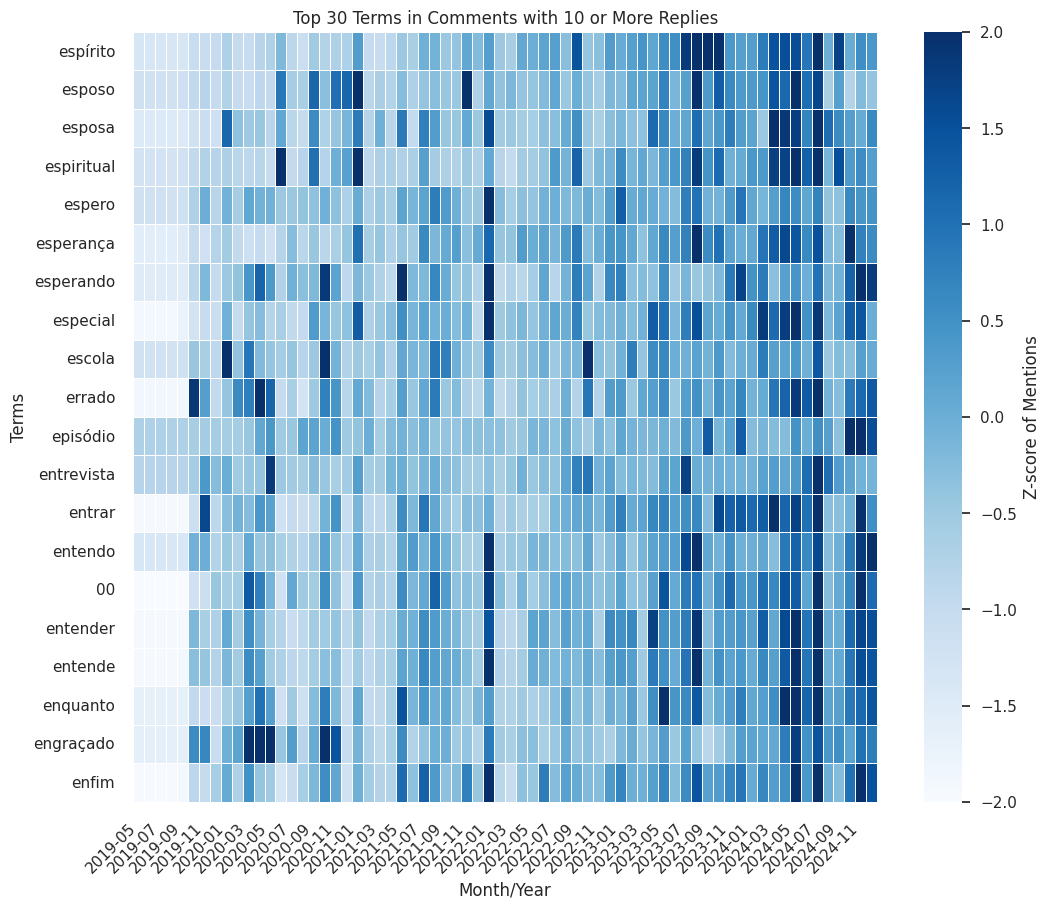

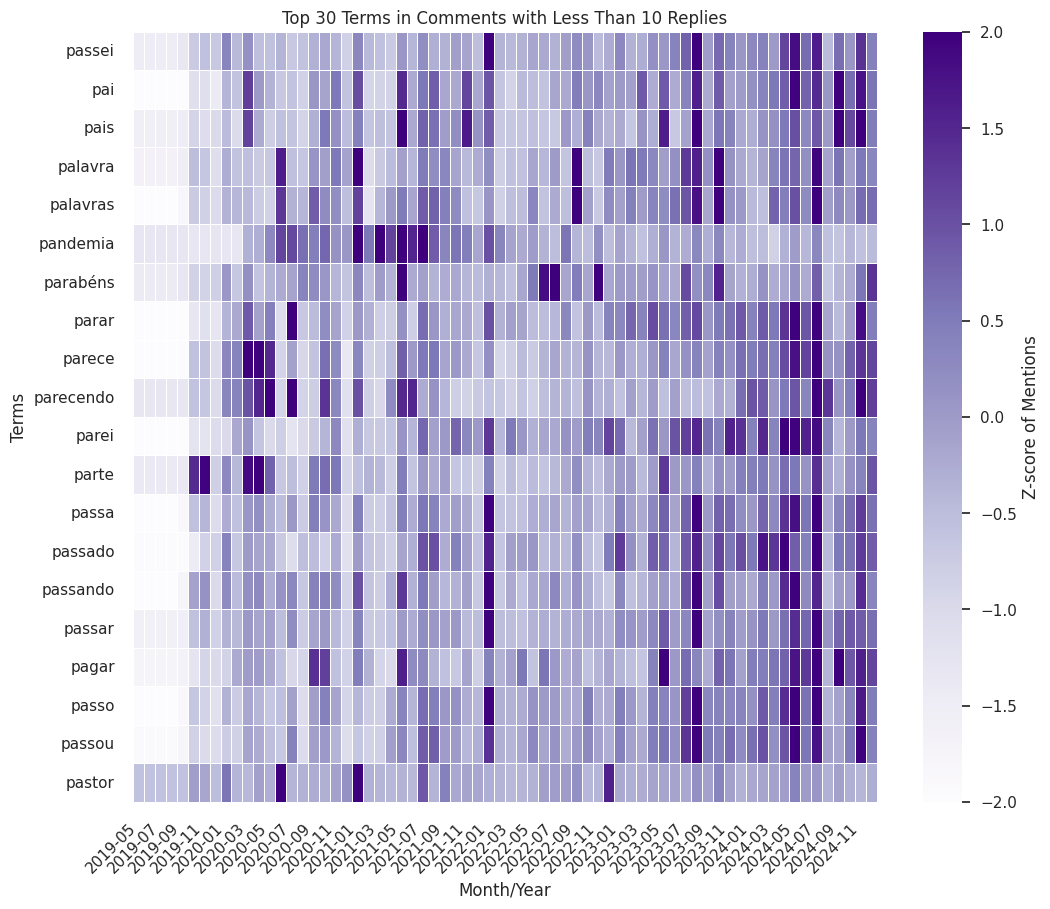

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import zscore
from nltk.corpus import stopwords
import nltk

# Certifique-se de baixar as stopwords do NLTK se ainda não tiver feito isso
nltk.download('stopwords')

# Obter stopwords em português
stop_words = set(stopwords.words('portuguese'))

# Adicionar stopwords personalizadas
custom_stopwords = set([
    'vai', 'ser', 'tá', 'tão', 'pra', 'né', 'vc', 'pq', 'isso', 'coisa', "vídeo", "video",
    'gente', 'aí', 'http', 'www', 'com', 'br', 'onde', 'tipo',"oi", "tô", "to", 
    "mano", "https", "sim", "não", "todos", "foda", "cara", "olá", "então", "faz", "vcs", "tá", 
    "ta", "kkk","kkkk","kkkkk","kkkkkk","kkkkkkk","kkkkkkkk", "fih"
])

# Atualizar as stopwords com as palavras personalizadas
stop_words.update(custom_stopwords)
stop_words = list(stop_words)  # Converter o conjunto atualizado para uma lista

# Convert 'published_at' to datetime if it's not already in datetime format
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.strftime('%Y-%m')

# Convert all comments to string to avoid erros
df['comment'] = df['comment'].apply(str)

# Identificar o comentário original e os replies
df['is_reply'] = df['comment_id'].str.contains('\.', regex=True)
df['original_comment_id'] = df['comment_id'].apply(lambda x: x.split('.')[0] if '.' in x else x)

# Filtrar apenas os comentários originais (excluindo os replies)
comments_df = df[df['is_reply'] == False]

# Contar o número de replies por comentário original
comments_df['num_replies'] = comments_df.groupby('original_comment_id')['comment_id'].transform('count') - 1
comments_df['num_replies'] = comments_df['num_replies'].fillna(0)  # Comentários sem replies terão zero

# Criar a classe de comentários com base no número de replies
comments_df['comment_class'] = comments_df['num_replies'].apply(lambda x: '10 or more replies' if x >= 10 else 'Less than 10 replies')

# Separar os comentários pelos dois grupos
more_replies_comments = comments_df[comments_df['comment_class'] == '10 or more replies']['comment']
less_replies_comments = comments_df[comments_df['comment_class'] == 'Less than 10 replies']['comment']

# Combinar os comentários em um DataFrame com a classe de comentário como rótulo
all_comments = pd.concat([more_replies_comments, less_replies_comments])
labels = ['10 or more replies'] * len(more_replies_comments) + ['Less than 10 replies'] * len(less_replies_comments)

# Criar o TF-IDF vetor considerando ambos os grupos juntos
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words=stop_words)
tfidf_matrix = tfidf_vectorizer.fit_transform(all_comments)

# Obter os termos e seus scores TF-IDF
terms = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()

# Calcular a média dos scores TF-IDF para cada grupo de comentários
more_replies_scores = tfidf_scores[:len(more_replies_comments)].mean(axis=0)
less_replies_scores = tfidf_scores[len(more_replies_comments):].mean(axis=0)

# Calcular a diferença entre os grupos para encontrar os termos mais discriminativos
score_diff = more_replies_scores - less_replies_scores

# Obter os termos mais representativos para cada grupo
top_more_replies_terms = [terms[i] for i in score_diff.argsort()[-20:][::-1]]
top_less_replies_terms = [terms[i] for i in score_diff.argsort()[:20]]

# Função para criar heatmaps
def plot_heatmap(term_list, color_map, title):
    # Inicializar um DataFrame para armazenar as contagens
    term_counts = pd.DataFrame(0, index=date_range.strftime('%Y-%m'), columns=term_list)

    # Contar a ocorrência de cada termo por mês
    for term in term_list:
        term_df = comments_df[comments_df['comment'].str.contains(term, case=False, na=False)]
        monthly_counts = term_df.groupby('month_year').size()
        term_counts[term].update(monthly_counts)

    # Remover colunas que são totalmente nulas
    term_counts = term_counts.loc[:, (term_counts != 0).any(axis=0)]

    # Normalizar o DataFrame pelo Z-score por coluna
    term_counts_zscore = term_counts.apply(zscore)

    # Plotar o heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(term_counts_zscore.T, cmap=color_map, cbar_kws={'label': 'Z-score of Mentions'}, linewidths=.5, vmin=-2, vmax=2)
    plt.title(title)
    plt.xlabel('Month/Year')
    plt.ylabel('Terms')

    # Personalizar os ticks do eixo X
    plt.xticks(rotation=45, ha='right')

    # Mostrar o gráfico
    plt.show()
    plt.close()

# Criar um range de datas para o DataFrame
date_range = pd.date_range(start=df['published_at'].min(), end=df['published_at'].max(), freq='MS')

# Plotar heatmap para os termos dos comentários com 10 ou mais replies
plot_heatmap(top_more_replies_terms, 'Blues', 'Top 30 Terms in Comments with 10 or More Replies')

# Plotar heatmap para os termos dos comentários com menos de 10 replies
plot_heatmap(top_less_replies_terms, 'Purples', 'Top 30 Terms in Comments with Less Than 10 Replies')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smartdata_ig/c.ferreira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


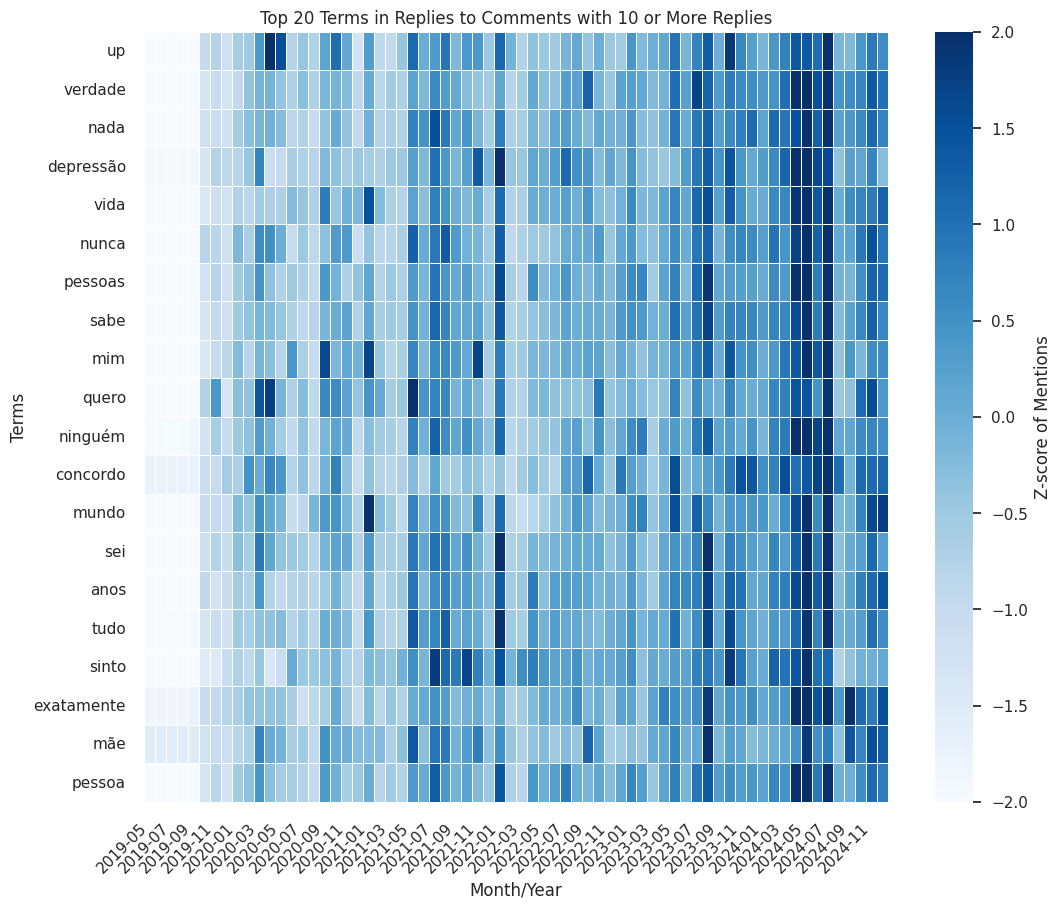

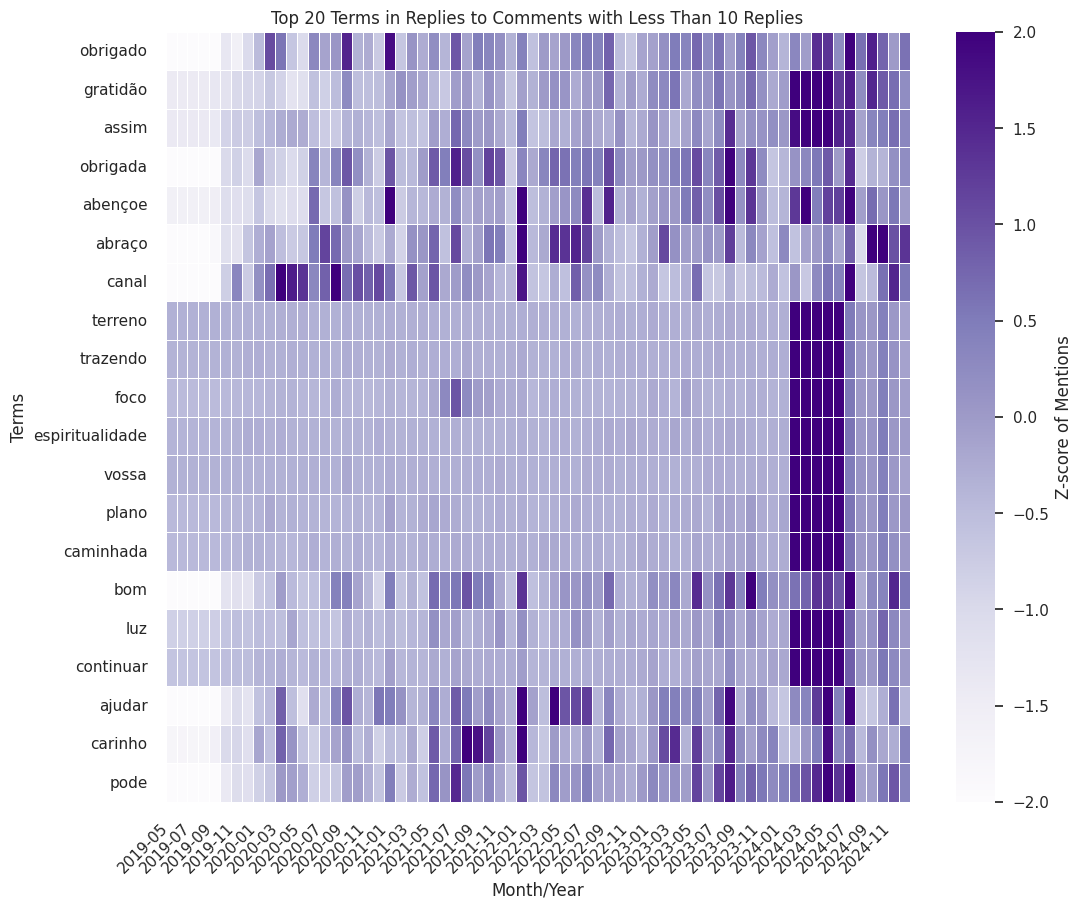

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import zscore
from nltk.corpus import stopwords
import nltk

# Certifique-se de baixar as stopwords do NLTK se ainda não tiver feito isso
nltk.download('stopwords')

# Obter stopwords em português
stop_words = set(stopwords.words('portuguese'))

# Adicionar stopwords personalizadas
custom_stopwords = set([
    'vai', 'ser', 'tá', 'tão', 'pra', 'né', 'vc', 'pq', 'isso', 'coisa', "vídeo", "video",
    'gente', 'aí', 'http', 'www', 'com', 'br', 'onde', 'tipo',"oi", "tô", "to", 
    "mano", "https", "sim", "não", "todos", "foda", "cara", "olá", "então", "faz", "vcs", "tá", 
    "ta", "kkk","kkkk","kkkkk","kkkkkk","kkkkkkk","kkkkkkkk", "fih"
])

# Atualizar as stopwords com as palavras personalizadas
stop_words.update(custom_stopwords)
stop_words = list(stop_words)  # Converter o conjunto atualizado para uma lista

# Convert 'published_at' to datetime if it's not already in datetime format
df['published_at'] = pd.to_datetime(df['published_at'])
df['month_year'] = df['published_at'].dt.strftime('%Y-%m')

# Convert all comments to string to avoid erros
df['comment'] = df['comment'].apply(str)

# Identificar o comentário original e os replies
df['is_reply'] = df['comment_id'].str.contains('\.', regex=True)

df['original_comment_id'] = df['comment_id'].apply(lambda x: x.split('.')[0] if '.' in x else x)

# Contar o número de replies por comentário original
df['num_replies'] = df.groupby('original_comment_id')['comment_id'].transform('count') - 1
df['num_replies'] = df['num_replies'].fillna(0)  # Comentários sem replies terão zero

# Criar a classe de comentários com base no número de replies
df['comment_class'] = df['num_replies'].apply(lambda x: '10 or more replies' if x >= 10 else 'Less than 10 replies')

# Filtrar apenas os replies
replies_df = df[df['is_reply'] == True]

# Separar os replies pelos dois grupos com base na classificação do comentário original
more_replies = replies_df[replies_df['comment_class'] == '10 or more replies']['comment']
less_replies = replies_df[replies_df['comment_class'] == 'Less than 10 replies']['comment']

# Combinar os replies em um DataFrame com a classe de comentário como rótulo
all_replies = pd.concat([more_replies, less_replies])
labels = ['10 or more replies'] * len(more_replies) + ['Less than 10 replies'] * len(less_replies)

# Criar o TF-IDF vetor considerando ambos os grupos juntos
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words=stop_words)
tfidf_matrix = tfidf_vectorizer.fit_transform(all_replies)

# Obter os termos e seus scores TF-IDF
terms = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.toarray()

# Calcular a média dos scores TF-IDF para cada grupo de replies
more_replies_scores = tfidf_scores[:len(more_replies)].mean(axis=0)
less_replies_scores = tfidf_scores[len(more_replies):].mean(axis=0)

# Calcular a diferença entre os grupos para encontrar os termos mais discriminativos
score_diff = more_replies_scores - less_replies_scores

# Obter os termos mais representativos para cada grupo
top_more_replies_terms = [terms[i] for i in score_diff.argsort()[-20:][::-1]]
top_less_replies_terms = [terms[i] for i in score_diff.argsort()[:20]]

# Função para criar heatmaps
def plot_heatmap(term_list, color_map, title):
    # Inicializar um DataFrame para armazenar as contagens
    term_counts = pd.DataFrame(0, index=date_range.strftime('%Y-%m'), columns=term_list)

    # Contar a ocorrência de cada termo por mês
    for term in term_list:
        term_df = df[df['comment'].str.contains(term, case=False, na=False)]
        monthly_counts = term_df.groupby('month_year').size()
        term_counts[term].update(monthly_counts)

    # Remover colunas que são totalmente nulas
    term_counts = term_counts.loc[:, (term_counts != 0).any(axis=0)]

    # Normalizar o DataFrame pelo Z-score por coluna
    term_counts_zscore = term_counts.apply(zscore)

    # Plotar o heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(term_counts_zscore.T, cmap=color_map, cbar_kws={'label': 'Z-score of Mentions'}, linewidths=.5, vmin=-2, vmax=2)
    plt.title(title)
    plt.xlabel('Month/Year')
    plt.ylabel('Terms')

    # Personalizar os ticks do eixo X
    plt.xticks(rotation=45, ha='right')

    # Mostrar o gráfico
    plt.show()
    plt.close()

# Criar um range de datas para o DataFrame
date_range = pd.date_range(start=df['published_at'].min(), end=df['published_at'].max(), freq='MS')

# Plotar heatmap para os termos dos replies a comentários com 10 ou mais replies
plot_heatmap(top_more_replies_terms, 'Blues', 'Top 20 Terms in Replies to Comments with 10 or More Replies')

# Plotar heatmap para os termos dos replies a comentários com menos de 10 replies
plot_heatmap(top_less_replies_terms, 'Purples', 'Top 20 Terms in Replies to Comments with Less Than 10 Replies')
